# 파이토치 환경 확인

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# 사이킷런 다운로드

In [2]:
!pip install -U scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   --------------------------- ------------ 5.5/8.1 MB 33.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 27.8 MB/s  0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ------------- -------------------------- 1/3 [joblib]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ------------- 2/3 [scikit-learn]
   -------------------------- ---------

# iris 신경망 v.pt

- Iris는 데이터가 작아 CPU로 충분합니다
- device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [7]:
# 1. 재현성 고정
torch.manual_seed(1)

# 2. 데이터 로드
iris = load_iris()
X = iris.data
y = iris.target
X.shape, y.shape

((150, 4), (150,))

In [8]:
# 3. train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=1, stratify=y
)

In [9]:
# 4. 스케일링 - array, 사이킷런 라이브러리
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
#5. Tensor 변환
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype= torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [11]:
#6. Dataset/Dataloader

train_dataset = TensorDataset(X_train,y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size = 16, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size= 16, shuffle= False)

In [15]:
#7. 신경망 모델 정의
class IrisNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,16) #입력 특성 4개
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(16,3) #출력 특성 3개
    
  def forward(self, x): # 순방향 학습
    x = self.fc1(x)
    x = self.relu(x)
    x = self.fc2(x)
    return x

In [16]:
model = IrisNet()
model

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)

In [17]:
# 8. 손실 함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [20]:
# 9. 학습 루프
num_epochs = 1000
loss_history = [] # <- 이 줄 추가

for epoch in range(num_epochs):
  model.train()
  running_loss = 0.0
  
  for x_batch, y_batch in train_loader:
    optimizer.zero_grad()                 #기울기 초기화
    outputs = model(x_batch)              #순전파
    loss = criterion(outputs, y_batch)    #손실 계산
    loss.backward()                       #역전파
    optimizer.step()                      #가중치 업데이트
    
    running_loss += loss.item()
    
  epoch_loss = running_loss / len(train_loader)
  loss_history.append(epoch_loss) # <- 이 줄 추가
  
  if (epoch + 1) % 10 == 0:
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [10/1000], Loss: 0.0585
Epoch [20/1000], Loss: 0.0468
Epoch [30/1000], Loss: 0.0435
Epoch [40/1000], Loss: 0.0474
Epoch [50/1000], Loss: 0.0434
Epoch [60/1000], Loss: 0.0479
Epoch [70/1000], Loss: 0.0468
Epoch [80/1000], Loss: 0.0440
Epoch [90/1000], Loss: 0.0403
Epoch [100/1000], Loss: 0.0460
Epoch [110/1000], Loss: 0.0424
Epoch [120/1000], Loss: 0.0409
Epoch [130/1000], Loss: 0.0393
Epoch [140/1000], Loss: 0.0424
Epoch [150/1000], Loss: 0.0397
Epoch [160/1000], Loss: 0.0381
Epoch [170/1000], Loss: 0.0443
Epoch [180/1000], Loss: 0.0549
Epoch [190/1000], Loss: 0.0374
Epoch [200/1000], Loss: 0.0381
Epoch [210/1000], Loss: 0.0368
Epoch [220/1000], Loss: 0.0377
Epoch [230/1000], Loss: 0.0423
Epoch [240/1000], Loss: 0.0393
Epoch [250/1000], Loss: 0.0409
Epoch [260/1000], Loss: 0.0385
Epoch [270/1000], Loss: 0.0432
Epoch [280/1000], Loss: 0.0410
Epoch [290/1000], Loss: 0.0375
Epoch [300/1000], Loss: 0.0402
Epoch [310/1000], Loss: 0.0376
Epoch [320/1000], Loss: 0.0378
Epoch [330/1000],

In [23]:
# 10. 평가

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for x_batch, y_batch in test_loader:
    outputs = model(x_batch)
    _, predicted = torch.max(outputs, 1)
    total += y_batch.size(0)
    correct += (predicted == y_batch).sum().item()
    
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy: .2f}%")

Test Accuracy:  97.78%


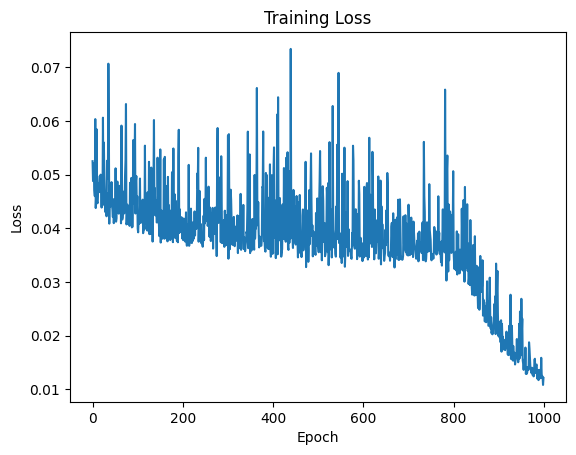

In [24]:
import matplotlib.pyplot as plt
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel('Loss')
plt.show()

In [27]:
# Day1-2_pytorch_mlp.ipynb

# 1. 환경 확인
import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# 2. 데이터셋 로드
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# 3. 모델 정의
import torch.nn as nn
import torch.nn.functional as F

class Mnistnet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

model = Mnistnet().to(device)

# 4. 손실함수와 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# 5. 학습 루프
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

# 6. 평가
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for X, y in test_loader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        _, preds = torch.max(outputs, 1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test Accuracy: {100 * correct / total:.2f}%")



PyTorch: 2.6.0+cu124
CUDA available: True
Using device: cuda
Epoch 1/5, Loss: 0.3352
Epoch 2/5, Loss: 0.1503
Epoch 3/5, Loss: 0.1110
Epoch 4/5, Loss: 0.0886
Epoch 5/5, Loss: 0.0754
Test Accuracy: 97.63%


In [26]:
!pip install -U torchsummary